In [1]:
from astroquery.mast import Catalogs, Observations
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import lightkurve as lk
from astropy.io import fits
import matplotlib.pyplot as plt


In [2]:
data_folder = '/Users/philvanlane/Documents/lc_ae/data/'
tics = pd.read_csv(data_folder + 'mocadb_add_TICS.csv',dtype={'TIC_ID': str})['TIC_ID'].values


In [3]:
tics

array(['305831074', '305825957', '2344582', ..., '243577886', '331080243',
       '243577780'], dtype=object)

## Light curves

In [4]:
sample_tic = '405461319'
sample_sector = 42

In [5]:
res = lk.search_lightcurve(f"TIC {sample_tic}", mission='TESS', author='SPOC', exptime=120, sector=sample_sector)

In [6]:
res

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 42,2021,SPOC,120,405461319,0.0


## Get camera/sector/CCD

In [98]:
df = pd.DataFrame(columns=['TIC_ID', 'mission', 'author', 'exptime'])

In [35]:
res = lk.search_lightcurve(f"TIC 43605290", mission='TESS')

In [36]:
res

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 05,2018,SPOC,120,471012347,0.0
1,TESS Sector 05,2018,SPOC,120,43605290,0.0
2,TESS Sector 32,2020,SPOC,20,471012347,0.0
3,TESS Sector 32,2020,SPOC,20,43605290,0.0
4,TESS Sector 32,2020,SPOC,120,471012347,0.0
5,TESS Sector 32,2020,SPOC,120,43605290,0.0
6,TESS Sector 98,2025,SPOC,20,471012347,0.0
7,TESS Sector 98,2025,SPOC,120,471012347,0.0
8,TESS Sector 05,2018,TESS-SPOC,1800,471012347,0.0


In [39]:
lc1 = res[0].download()
lc2 = res[1].download()

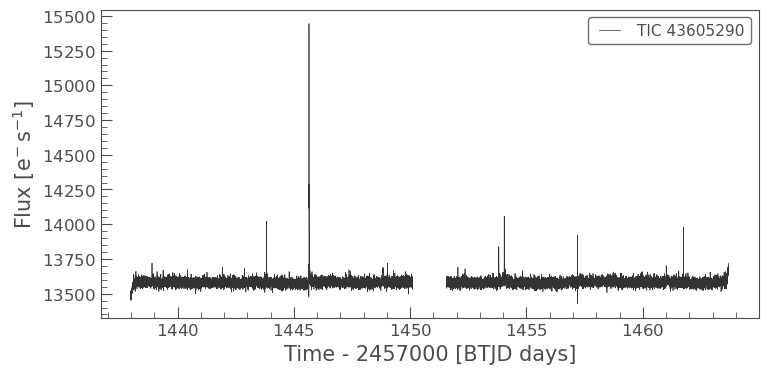

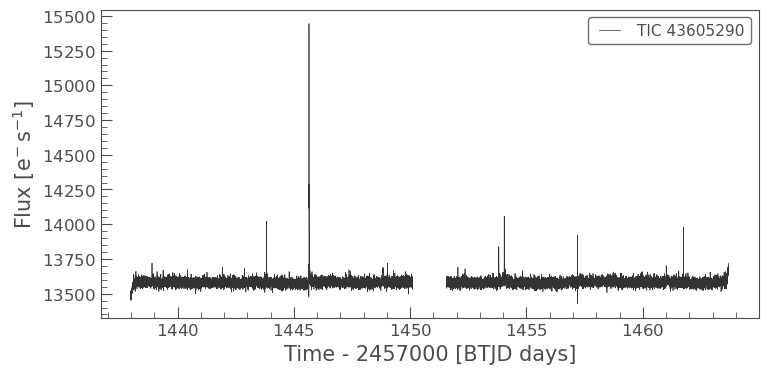

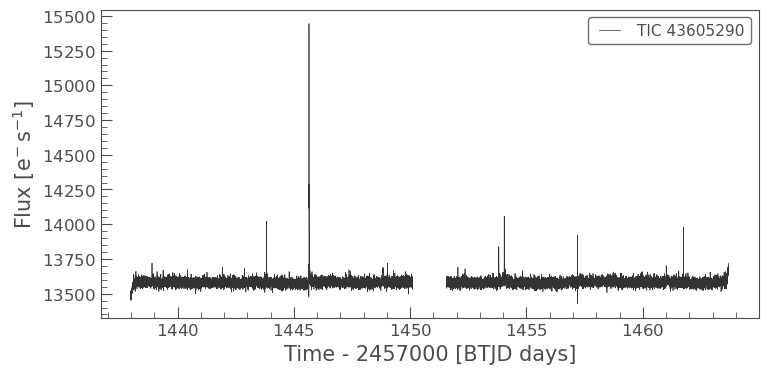

In [44]:
lc2.plot()
plt.show()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

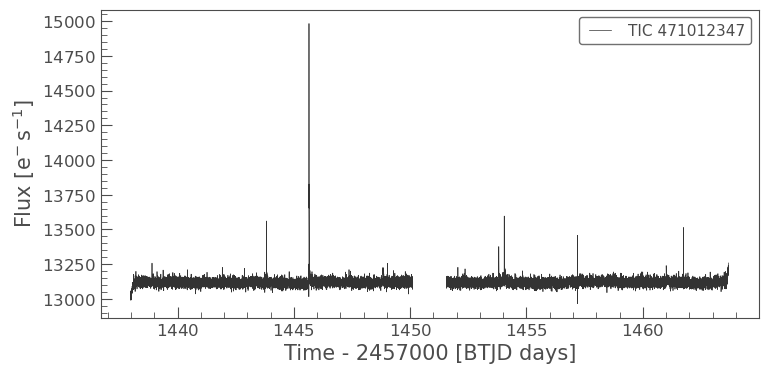

In [40]:
lc1.plot()

In [14]:
res = lk.search_lightcurve(f"TIC {tics[201]}", mission='TESS', author='SPOC', exptime=120)

No data found for target "TIC 68274522".


In [21]:
df

,TIC_ID,mission,author,exptime,year,target_name


In [24]:
# df = pd.DataFrame(columns=['TIC_ID', 'mission', 'author', 'exptime', 'year', 'target_name'])

for i in range(len(tics)):
    if len(df.loc[df['TIC_ID'] == tics[i]]) > 0:
        continue
    if i % 100 == 0:
        print(f"Processing TIC {i}/{len(tics)}")
    res = lk.search_lightcurve(f"TIC {tics[i]}", mission='TESS', author='SPOC', exptime=120)
    for j in range(len(res)):
        df_record = pd.DataFrame({
            'TIC_ID': [tics[i]],
            'mission': [res.mission[j]],
            'author': [res.author.data[j]],
            'exptime': [res.exptime[j]],
            'year': [res.year[j]],
            'target_name': [res.target_name[j]]
        })
        df = pd.concat([df, df_record], ignore_index=True)


Processing TIC 0/3427
Processing TIC 100/3427
Processing TIC 200/3427
Processing TIC 300/3427
Processing TIC 400/3427
Processing TIC 500/3427
Processing TIC 600/3427
Processing TIC 700/3427
Processing TIC 800/3427
Processing TIC 900/3427
Processing TIC 1000/3427
Processing TIC 1100/3427
Processing TIC 1200/3427
Processing TIC 1300/3427
Processing TIC 1400/3427
Processing TIC 1500/3427
Processing TIC 1600/3427
Processing TIC 1700/3427
Processing TIC 1800/3427
Processing TIC 1900/3427
Processing TIC 2000/3427
Processing TIC 2100/3427
Processing TIC 2200/3427
Processing TIC 2300/3427
Processing TIC 2500/3427
Processing TIC 2600/3427
Processing TIC 2700/3427
Processing TIC 2900/3427
Processing TIC 3000/3427


No data found for target "TIC 220188591".
No data found for target "TIC 220188569".
No data found for target "TIC 220188289".
No data found for target "TIC 220135929".
No data found for target "TIC 220135827".
No data found for target "TIC 220136048".
No data found for target "TIC 220188086".
No data found for target "TIC 220188003".
No data found for target "TIC 220135913".
No data found for target "TIC 220188285".
No data found for target "TIC 220188443".
No data found for target "TIC 220155257".
No data found for target "TIC 220136064".
No data found for target "TIC 220154227".
No data found for target "TIC 220155235".
No data found for target "TIC 220188109".
No data found for target "TIC 220154760".
No data found for target "TIC 220188431".
No data found for target "TIC 220155278".
No data found for target "TIC 220188487".
No data found for target "TIC 220188083".
No data found for target "TIC 220155417".
No data found for target "TIC 220188140".
No data found for target "TIC 2201

Processing TIC 3100/3427


No data found for target "TIC 220155270".
No data found for target "TIC 220154692".
No data found for target "TIC 220136245".
No data found for target "TIC 220188068".
No data found for target "TIC 220155085".
No data found for target "TIC 220155393".
No data found for target "TIC 220154564".
No data found for target "TIC 220154820".
No data found for target "TIC 220154702".
No data found for target "TIC 220154553".
No data found for target "TIC 220155357".
No data found for target "TIC 220187957".
No data found for target "TIC 220154505".
No data found for target "TIC 220155431".
No data found for target "TIC 220155099".
No data found for target "TIC 220154965".
No data found for target "TIC 220155211".
No data found for target "TIC 220154781".
No data found for target "TIC 220136092".
No data found for target "TIC 220154748".
No data found for target "TIC 220154978".
No data found for target "TIC 220136144".
No data found for target "TIC 220137121".
No data found for target "TIC 2201

Processing TIC 3200/3427


No data found for target "TIC 220154017".
No data found for target "TIC 220154524".
No data found for target "TIC 220137069".
No data found for target "TIC 220155066".
No data found for target "TIC 220136640".
No data found for target "TIC 220155388".
No data found for target "TIC 220154603".
No data found for target "TIC 220154730".
No data found for target "TIC 220154912".
No data found for target "TIC 220154810".
No data found for target "TIC 220136153".
No data found for target "TIC 220155071".
No data found for target "TIC 220155202".
No data found for target "TIC 220155354".
No data found for target "TIC 220155165".
No data found for target "TIC 220154661".
No data found for target "TIC 220155237".
No data found for target "TIC 220155307".
No data found for target "TIC 220154727".
No data found for target "TIC 220154996".
No data found for target "TIC 220155341".
No data found for target "TIC 220154625".
No data found for target "TIC 220155097".
No data found for target "TIC 2201

Processing TIC 3300/3427


No data found for target "TIC 220154055".
No data found for target "TIC 220154556".
No data found for target "TIC 220154291".
No data found for target "TIC 220136281".
No data found for target "TIC 220136587".
No data found for target "TIC 220155186".
No data found for target "TIC 220136561".
No data found for target "TIC 220153916".
No data found for target "TIC 220154425".
No data found for target "TIC 220136658".
No data found for target "TIC 220136635".
No data found for target "TIC 220154999".
No data found for target "TIC 220136565".
No data found for target "TIC 220155011".
No data found for target "TIC 220155164".
No data found for target "TIC 220154112".
No data found for target "TIC 220136645".
No data found for target "TIC 220154240".
No data found for target "TIC 220136811".
No data found for target "TIC 220154178".
No data found for target "TIC 220153904".
No data found for target "TIC 220136667".
No data found for target "TIC 220155008".
No data found for target "TIC 2201

Processing TIC 3400/3427


No data found for target "TIC 220188023".
No data found for target "TIC 220155145".
No data found for target "TIC 268149914".
No data found for target "TIC 268280319".
No data found for target "TIC 280117086".
No data found for target "TIC 280422383".
No data found for target "TIC 310536737".
No data found for target "TIC 310483731".
No data found for target "TIC 310483838".
No data found for target "TIC 310483992".
No data found for target "TIC 310386003".
No data found for target "TIC 310386734".
No data found for target "TIC 310386708".
No data found for target "TIC 310483644".
No data found for target "TIC 13970046".
No data found for target "TIC 419366466".
No data found for target "TIC 426553833".
No data found for target "TIC 428023413".
No data found for target "TIC 349588004".
No data found for target "TIC 168016675".
No data found for target "TIC 168399023".
No data found for target "TIC 168020444".
No data found for target "TIC 331092487".
No data found for target "TIC 24357

In [16]:
df

,TIC_ID,mission,author,exptime,year,target_name
0,4374147,TESS Sector 20,SPOC,120.0 s,2019,4374147
1,17901654,TESS Sector 20,SPOC,120.0 s,2019,17901654
2,97314759,TESS Sector 44,SPOC,120.0 s,2021,97314759
3,97314759,TESS Sector 45,SPOC,120.0 s,2021,97314759
4,97314759,TESS Sector 46,SPOC,120.0 s,2021,97314759
...,...,...,...,...,...,...
144,130700676,TESS Sector 92,SPOC,120.0 s,2025,130700676
145,130931009,TESS Sector 92,SPOC,120.0 s,2025,130931009
146,130289670,TESS Sector 92,SPOC,120.0 s,2025,130289670
147,130631147,TESS Sector 54,SPOC,120.0 s,2022,130631147


In [31]:
df['TIC_ID'] = df['TIC_ID'].astype(str)
df['target_name'] = df['target_name'].astype(str)

In [32]:
df[df['TIC_ID'].astype(str) == df['target_name'].astype(str)]

,TIC_ID,mission,author,exptime,year,target_name
0,72437047,TESS Sector 49,SPOC,120.0 s,2022,72437047
1,230061010,TESS Sector 14,SPOC,120.0 s,2019,230061010
2,230061010,TESS Sector 15,SPOC,120.0 s,2019,230061010
3,230061010,TESS Sector 16,SPOC,120.0 s,2019,230061010
4,230061010,TESS Sector 20,SPOC,120.0 s,2019,230061010
...,...,...,...,...,...,...
20051,268403451,TESS Sector 79,SPOC,120.0 s,2024,268403451
20052,268403451,TESS Sector 86,SPOC,120.0 s,2024,268403451
20053,439403362,TESS Sector 03,SPOC,120.0 s,2018,439403362
20054,439403362,TESS Sector 30,SPOC,120.0 s,2020,439403362


In [19]:
np.where(tics == '338674556')

(array([2999]),)

In [13]:
tics[374]

53458803

In [41]:
len(tics_pt3)

5490

In [44]:
df

,TIC_ID,mission,author,exptime,year,target_name
0,138685655,TESS Sector 42,SPOC,120.0 s,2021,138685655
1,118585685,TESS Sector 02,SPOC,120.0 s,2018,118585685
2,118585685,TESS Sector 29,SPOC,120.0 s,2020,118585685
3,118585685,TESS Sector 69,SPOC,120.0 s,2023,118585685
4,118585685,TESS Sector 96,SPOC,120.0 s,2025,118585685
...,...,...,...,...,...,...
12067,129634216,TESS Sector 57,SPOC,120.0 s,2022,129634216
12068,423975007,TESS Sector 57,SPOC,120.0 s,2022,423975007
12069,423975007,TESS Sector 84,SPOC,120.0 s,2024,423975007
12070,283789204,TESS Sector 57,SPOC,120.0 s,2022,283789204


In [19]:
df.to_csv(data_folder + 'lcs.csv', index=False)

## Get camera/sector/ccd

### Sample

In [44]:
sample_tic = '405461319'
sample_sector = 42

In [45]:
res = lk.search_lightcurve(f"TIC {sample_tic}", mission='TESS', author='SPOC', exptime=120, sector=sample_sector)

In [46]:
mast_uri = res.table['dataURL'][0]
url = f"https://mast.stsci.edu/api/v0.1/Download/file?uri={mast_uri}"

with fits.open(url, memmap=False) as hdul:
    hdr = hdul[0].header
    print(hdr["SECTOR"], hdr["CAMERA"], hdr["CCD"])

42 4 4


### For all curves

In [49]:
df = pd.read_csv(data_folder + 'CF_TIC_sectors.csv')

In [54]:
df.to_csv(data_folder + 'CF_TIC_with_sector_camera_ccd.csv', index=False)

In [58]:
df

,TIC_ID,sector,cadence_s,year,SECTOR,CAMERA,CCD
0,405461319,42,120,2021,42,4,4
1,405461319,43,120,2021,43,3,1
2,177990792,18,120,2019,18,1,1
3,177990792,58,120,2022,58,1,4
4,177990792,85,120,2024,85,1,4
...,...,...,...,...,...,...,...
7906,353928999,43,120,2021,None,None,None
7907,353928999,44,120,2021,None,None,None
7908,353928999,58,120,2022,None,None,None
7909,353928999,70,120,2023,None,None,None


In [75]:
df_searched = df[df['SECTOR'].notna()]
print('max index searched:', np.max(df_searched.index.values))

max index searched: 7872


In [76]:
# df['SECTOR'] = None
# df['CAMERA'] = None
# df['CCD'] = None

for i,r in df.iterrows():
    if i % 500 == 0:
        print(f"Processing TIC {i}/{len(df)}")
    if r['CCD'] is not None and r['CAMERA'] is not None and r['SECTOR'] is not None:
        continue
    tic_id = r['TIC_ID']
    res = lk.search_lightcurve(f"TIC {tic_id}", mission='TESS', author='SPOC', exptime=120, sector=r['sector'])
    if len(res) > 0:
        mast_uri = res.table['dataURL'][0]
        url = f"https://mast.stsci.edu/api/v0.1/Download/file?uri={mast_uri}"
        with fits.open(url, memmap=False) as hdul:
            hdr = hdul[0].header
            df.at[i, 'SECTOR'] = hdr.get("SECTOR", None)
            df.at[i, 'CAMERA'] = hdr.get("CAMERA", None)
            df.at[i, 'CCD'] = hdr.get("CCD", None)

Processing TIC 0/7911
Processing TIC 500/7911
Processing TIC 1000/7911
Processing TIC 1500/7911
Processing TIC 2000/7911
Processing TIC 2500/7911
Processing TIC 3000/7911
Processing TIC 3500/7911
Processing TIC 4000/7911
Processing TIC 4500/7911
Processing TIC 5000/7911
Processing TIC 5500/7911
Processing TIC 6000/7911
Processing TIC 6500/7911
Processing TIC 7000/7911
Processing TIC 7500/7911


In [78]:
df.to_csv(data_folder + 'CF_TIC_with_sector_camera_ccd.csv', index=False)